# EEG Pain Outcome Prediction Pipeline

Predict **T2-T1 pain change** (Diff) using baseline EEG features.

### Strategy
- Small dataset (n≈74 with EEG+outcome): prioritise regularised, low-complexity models
- **Nested cross-validation** avoids optimistic bias in model selection
- **Permutation test** verifies performance is above chance
- Clinical covariates (baseline pain, group, age …) often dominate EEG in small studies
- Multiple feature sets tested; best combination reported

### Target variants
| Task | Target |
|------|--------|
| Regression | Continuous Diff |
| Binary classification | Diff < median vs ≥ median |
| 3-class classification | Diff<−3 / −3≤Diff≤−2 / Diff>−2 |


In [1]:
# ── 0. Imports ──────────────────────────────────────────────────────────────
import warnings, re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from scipy import stats

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_regression, f_classif

from sklearn.linear_model import Ridge, Lasso, ElasticNet, BayesianRidge, LogisticRegression
from sklearn.svm import SVR, SVC
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor, GradientBoostingClassifier

from sklearn.model_selection import (
    StratifiedKFold, KFold, cross_val_score,
    GridSearchCV, permutation_test_score
)
from sklearn.metrics import (
    mean_absolute_error, r2_score,
    balanced_accuracy_score, roc_auc_score,
    ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
np.random.seed(42)

BASE_DIR = Path('.')
DATA_DIR = BASE_DIR / 'processeddata'

print('All imports OK')

All imports OK


## 1. Load Outcomes & Clinical Variables

In [2]:
# ── 1. Load outcomes ─────────────────────────────────────────────────────────
outcomes_path = DATA_DIR / 'Randomization factors and Primary outcome.xlsx'
raw_df = pd.read_excel(outcomes_path)

# Pivot T1/T2 pain scores per patient
pain = raw_df[raw_df['Event Name'].isin(['T1','T2'])].pivot_table(
    index='Patient number', columns='Event Name', values='Pain Unpleasantness'
)
pain['Diff'] = pain['T2'] - pain['T1']

# Grab clinical covariates from T1 rows only
t1_rows = raw_df[raw_df['Event Name'] == 'T1'].copy()
t1_rows = t1_rows.set_index('Patient number')

GROUP_COL  = 'Group assignment - can code the variables (NFB=1; NFB+DL=2; DL=3)'
MONTHS_COL = 'How many months have you been experiencing neuropathy?'

clinical = pd.DataFrame({
    'T1_pain': pain['T1'],
    'Diff':    pain['Diff'],
    'Age':     t1_rows['Age'],
    'Sex':     t1_rows['Sex:'].map({'Female': 0, 'Male': 1}),
    'Group':   t1_rows[GROUP_COL].map({'NFB': 0, 'NFB+DL': 1, 'DL': 2}),
    # Many free-text entries — coerce non-numerics to NaN (imputed later)
    'NeuropMonths': pd.to_numeric(t1_rows[MONTHS_COL], errors='coerce'),
})

print(f"Outcome table shape: {clinical.shape}")
print(f"Diff stats:\n{clinical['Diff'].describe().round(2)}")
print(f"\nGroup distribution:\n{clinical['Group'].value_counts()}")

Outcome table shape: (336, 6)
Diff stats:
count    181.00
mean      -2.52
std        2.36
min      -10.00
25%       -4.00
50%       -2.00
75%       -1.00
max        4.00
Name: Diff, dtype: float64

Group distribution:
Group
0.0    141
1.0     92
2.0     57
Name: count, dtype: int64


In [3]:
# ── 1b. Identify EEG patients and build patient index ────────────────────────
eeg_files = {}
for f in sorted(DATA_DIR.glob('CIPN3*.xlsx')):
    m = re.search(r'CIPN3(\d+)', f.name)
    if m:
        pid = int(m.group(1))
        eeg_files[pid] = f

# Keep only patients with EEG data AND a valid Diff score
common_ids = sorted(
    set(eeg_files.keys()) & set(clinical.index[clinical['Diff'].notna()])
)
print(f"Patients with EEG: {len(eeg_files)}")
print(f"Patients with Diff outcome: {clinical['Diff'].notna().sum()}")
print(f"Overlap (analysis set): {len(common_ids)}")

# Outcome series aligned to common_ids
y_reg   = clinical.loc[common_ids, 'Diff'].values.astype(float)  # continuous
y_bin   = (y_reg < np.median(y_reg)).astype(int)                 # 0=improved more, 1=less
vmin, vmax = -3.0, -2.0
y_tri   = np.where(y_reg < vmin, 0, np.where(y_reg > vmax, 2, 1)).astype(int)  # 3-class

median_diff = np.median(y_reg)
print(f"\nMedian Diff: {median_diff:.1f}")
print(f"Binary (0=Diff<median, 1=Diff>=median): {np.bincount(y_bin)}")
print(f"3-class distribution: {np.bincount(y_tri)}")

Patients with EEG: 78
Patients with Diff outcome: 181
Overlap (analysis set): 75

Median Diff: -3.0
Binary (0=Diff<median, 1=Diff>=median): [50 25]
3-class distribution: [25 29 21]


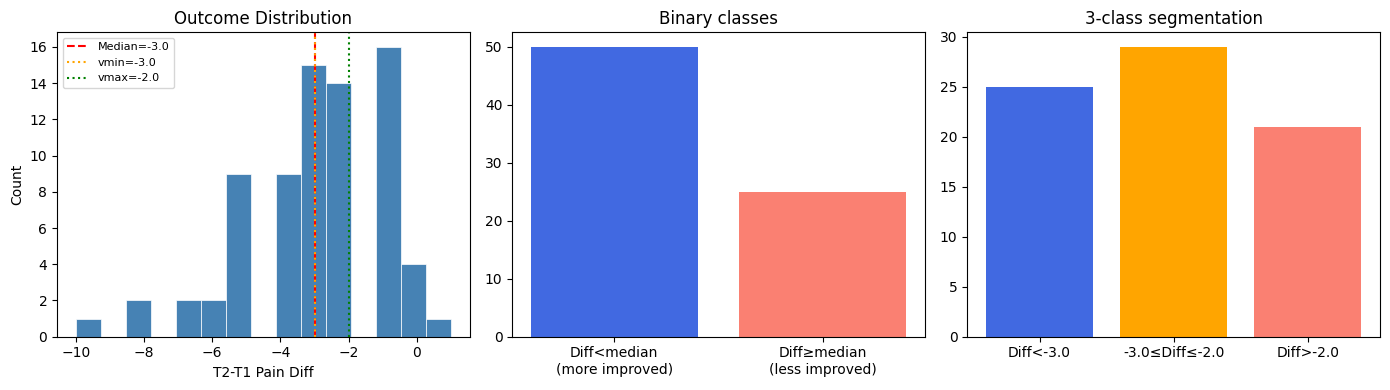


Baseline regression MAE (predict mean): 1.604


In [4]:
# ── 1c. Visualise outcome distribution ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(y_reg, bins=15, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].axvline(median_diff, color='red', linestyle='--', label=f'Median={median_diff:.1f}')
axes[0].axvline(vmin, color='orange', linestyle=':', label=f'vmin={vmin}')
axes[0].axvline(vmax, color='green',  linestyle=':', label=f'vmax={vmax}')
axes[0].set_xlabel('T2-T1 Pain Diff'); axes[0].set_ylabel('Count')
axes[0].set_title('Outcome Distribution'); axes[0].legend(fontsize=8)

labels_bin  = ['Diff<median\n(more improved)', 'Diff≥median\n(less improved)']
axes[1].bar(labels_bin, np.bincount(y_bin), color=['royalblue','salmon'])
axes[1].set_title('Binary classes')

labels_tri = [f'Diff<{vmin}', f'{vmin}≤Diff≤{vmax}', f'Diff>{vmax}']
axes[2].bar(labels_tri, np.bincount(y_tri), color=['royalblue','orange','salmon'])
axes[2].set_title('3-class segmentation')

plt.tight_layout(); plt.show()
print(f"\nBaseline regression MAE (predict mean): {mean_absolute_error(y_reg, np.full_like(y_reg, y_reg.mean())):.3f}")

## 2. Feature Engineering

Build multiple feature sets:
- **Clinical**: age, sex, group, baseline pain, neuropathy months  
- **EEG (per sheet)**: mean across channels for each frequency band  
- **EEG + Clinical**: concatenated  
- **PCA-reduced EEG**: top principal components  

In [5]:
# ── 2a. Helper to load one EEG sheet and extract features ───────────────────
def load_sheet_features(patient_ids, sheet_name):
    """
    For each patient, load `sheet_name`, compute per-column mean & std across
    channels (rows).  Returns a DataFrame (patients × 2*bands).
    """
    rows = {}
    for pid in patient_ids:
        try:
            sheet = pd.read_excel(eeg_files[pid], sheet_name=sheet_name, index_col=0)
            if sheet.empty:
                continue
            means = sheet.mean(axis=0).add_prefix('mean_')
            stds  = sheet.std(axis=0).add_prefix('std_')
            rows[pid] = pd.concat([means, stds])
        except Exception:
            pass
    df = pd.DataFrame(rows).T
    df.index.name = 'Patient'
    return df


# ── 2b. Load all relevant EEG sheets ────────────────────────────────────────
EEG_SHEETS = [
    'FFT_abs_bandpower_uV2',
    'FFT_rel_bandpower_pct',
    'Z_FFT_abs_bandpower_uV2',
    'Z_FFT_rel_bandpower_pct',
    'PeakFreq_Hz',
    'FFT_Coherence',
    'Z_FFT_Coherence',
    'FFT_PhaseLag_PLI',
    'Z_FFT_PhaseLag_PLI',
]

print('Loading EEG feature sheets ...')
eeg_sheet_dfs = {}
for sname in EEG_SHEETS:
    df_s = load_sheet_features(common_ids, sname)
    # keep only rows with ≥75% non-NaN features
    thresh = 0.75 * df_s.shape[1]
    df_s = df_s[df_s.notna().sum(axis=1) >= thresh]
    eeg_sheet_dfs[sname] = df_s
    print(f"  {sname:35s}: {df_s.shape[0]} patients, {df_s.shape[1]} features")

Loading EEG feature sheets ...
  FFT_abs_bandpower_uV2              : 75 patients, 28 features
  FFT_rel_bandpower_pct              : 75 patients, 28 features
  Z_FFT_abs_bandpower_uV2            : 75 patients, 20 features
  Z_FFT_rel_bandpower_pct            : 75 patients, 20 features
  PeakFreq_Hz                        : 75 patients, 28 features
  FFT_Coherence                      : 75 patients, 20 features
  Z_FFT_Coherence                    : 75 patients, 20 features
  FFT_PhaseLag_PLI                   : 75 patients, 20 features
  Z_FFT_PhaseLag_PLI                 : 75 patients, 20 features


In [6]:
# ── 2c. Build consolidated feature sets ─────────────────────────────────────
# Clinical features (always aligned to common_ids)
clin_df = clinical.loc[common_ids, ['T1_pain','Age','Sex','Group','NeuropMonths']].copy()

def align(feature_df, patient_ids):
    """Reindex to patient_ids and fill missing rows with NaN columns."""
    return feature_df.reindex(patient_ids)

# Power-based EEG (abs + rel + z-scored)
power_df = pd.concat([
    align(eeg_sheet_dfs.get('FFT_abs_bandpower_uV2', pd.DataFrame()), common_ids),
    align(eeg_sheet_dfs.get('FFT_rel_bandpower_pct', pd.DataFrame()), common_ids),
], axis=1)

# Z-scored power
zpower_df = pd.concat([
    align(eeg_sheet_dfs.get('Z_FFT_abs_bandpower_uV2', pd.DataFrame()), common_ids),
    align(eeg_sheet_dfs.get('Z_FFT_rel_bandpower_pct', pd.DataFrame()), common_ids),
], axis=1)

# Connectivity
conn_df = pd.concat([
    align(eeg_sheet_dfs.get('FFT_Coherence',     pd.DataFrame()), common_ids),
    align(eeg_sheet_dfs.get('Z_FFT_Coherence',   pd.DataFrame()), common_ids),
    align(eeg_sheet_dfs.get('FFT_PhaseLag_PLI',  pd.DataFrame()), common_ids),
    align(eeg_sheet_dfs.get('Z_FFT_PhaseLag_PLI',pd.DataFrame()), common_ids),
], axis=1)

# All EEG
all_eeg_df = pd.concat([
    align(df_s, common_ids) for df_s in eeg_sheet_dfs.values()
], axis=1)

# Combined EEG + clinical
eeg_clin_df = pd.concat([all_eeg_df, clin_df], axis=1)

FEATURE_SETS = {
    'Clinical only':       clin_df,
    'Power (raw)':         power_df,
    'Power (z-scored)':    zpower_df,
    'Connectivity':        conn_df,
    'All EEG':             all_eeg_df,
    'EEG + Clinical':      eeg_clin_df,
}

for name, df_ in FEATURE_SETS.items():
    print(f"  {name:25s}: {df_.shape}")

  Clinical only            : (75, 5)
  Power (raw)              : (75, 56)
  Power (z-scored)         : (75, 40)
  Connectivity             : (75, 80)
  All EEG                  : (75, 204)
  EEG + Clinical           : (75, 209)


## 3. Model Zoo

In [7]:
# ── 3. Define pipelines + hyperparameter grids ───────────────────────────────
# Preprocessing block: impute NaN → scale → optional PCA
def make_preproc(use_pca=False, n_pca=10):
    steps = [
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
    ]
    if use_pca:
        steps.append(('pca', PCA(n_components=n_pca, random_state=42)))
    return steps


# ── Regression models ────────────────────────────────────────────────────────
REG_MODELS = {
    'Ridge': (
        Pipeline(make_preproc() + [('model', Ridge())]),
        {'model__alpha': [0.01, 0.1, 1, 10, 100, 1000]}
    ),
    'Lasso': (
        Pipeline(make_preproc() + [('model', Lasso(max_iter=5000))]),
        {'model__alpha': [0.001, 0.01, 0.1, 0.5, 1, 5]}
    ),
    'ElasticNet': (
        Pipeline(make_preproc() + [('model', ElasticNet(max_iter=5000))]),
        {'model__alpha': [0.01, 0.1, 1], 'model__l1_ratio': [0.2, 0.5, 0.8]}
    ),
    'BayesianRidge': (
        Pipeline(make_preproc() + [('model', BayesianRidge())]),
        {}
    ),
    'SVR-RBF': (
        Pipeline(make_preproc() + [('model', SVR(kernel='rbf'))]),
        {'model__C': [0.1, 1, 10, 100], 'model__gamma': ['scale','auto']}
    ),
    'SVR-linear': (
        Pipeline(make_preproc() + [('model', SVR(kernel='linear'))]),
        {'model__C': [0.01, 0.1, 1, 10]}
    ),
    'RF-Regressor': (
        Pipeline(make_preproc() + [('model', RandomForestRegressor(random_state=42))]),
        {'model__n_estimators': [100, 300], 'model__max_depth': [2, 3, 5, None]}
    ),
    'GBT-Regressor': (
        Pipeline(make_preproc() + [('model', GradientBoostingRegressor(random_state=42))]),
        {'model__n_estimators': [50, 100], 'model__max_depth': [1, 2, 3], 'model__learning_rate': [0.05, 0.1]}
    ),
    'Ridge+PCA': (
        Pipeline(make_preproc(use_pca=True, n_pca=10) + [('model', Ridge())]),
        {'model__alpha': [0.01, 0.1, 1, 10, 100]}
    ),
    'SVR+PCA': (
        Pipeline(make_preproc(use_pca=True, n_pca=10) + [('model', SVR(kernel='rbf'))]),
        {'model__C': [0.1, 1, 10], 'model__gamma': ['scale','auto']}
    ),
}

# ── Classification models ────────────────────────────────────────────────────
CLF_MODELS = {
    'LogReg-L2': (
        Pipeline(make_preproc() + [('model', LogisticRegression(max_iter=2000, random_state=42))]),
        {'model__C': [0.001, 0.01, 0.1, 1, 10]}
    ),
    'LogReg-L1': (
        Pipeline(make_preproc() + [('model', LogisticRegression(penalty='l1', solver='saga', max_iter=2000, random_state=42))]),
        {'model__C': [0.001, 0.01, 0.1, 1, 10]}
    ),
    'SVM-RBF': (
        Pipeline(make_preproc() + [('model', SVC(kernel='rbf', probability=True, random_state=42))]),
        {'model__C': [0.1, 1, 10, 100], 'model__gamma': ['scale','auto']}
    ),
    'SVM-linear': (
        Pipeline(make_preproc() + [('model', SVC(kernel='linear', probability=True, random_state=42))]),
        {'model__C': [0.01, 0.1, 1, 10]}
    ),
    'RF-Classifier': (
        Pipeline(make_preproc() + [('model', RandomForestClassifier(random_state=42, class_weight='balanced'))]),
        {'model__n_estimators': [100, 300], 'model__max_depth': [2, 3, 5, None]}
    ),
    'GBT-Classifier': (
        Pipeline(make_preproc() + [('model', GradientBoostingClassifier(random_state=42))]),
        {'model__n_estimators': [50, 100], 'model__max_depth': [1, 2, 3], 'model__learning_rate': [0.05, 0.1]}
    ),
    'LogReg+PCA': (
        Pipeline(make_preproc(use_pca=True, n_pca=10) + [('model', LogisticRegression(max_iter=2000, random_state=42))]),
        {'model__C': [0.001, 0.01, 0.1, 1, 10]}
    ),
    'SVM+PCA': (
        Pipeline(make_preproc(use_pca=True, n_pca=10) + [('model', SVC(kernel='rbf', probability=True, random_state=42))]),
        {'model__C': [0.1, 1, 10], 'model__gamma': ['scale','auto']}
    ),
}

print(f"Regression models: {len(REG_MODELS)}")
print(f"Classification models: {len(CLF_MODELS)}")

Regression models: 10
Classification models: 8


## 4. Nested Cross-Validation Sweep

In [8]:
# ── 4a. Nested CV helper ─────────────────────────────────────────────────────
def nested_cv_regression(X_raw, y, model_dict, outer_cv, inner_cv):
    """
    For each model in model_dict run nested CV:
      outer fold: evaluate on held-out set
      inner fold: GridSearch for hyperparams
    Returns DataFrame with MAE, R² per model.
    """
    results = []
    n_samples = X_raw.shape[0]
    baseline_mae = mean_absolute_error(y, np.full(n_samples, y.mean()))

    for mname, (pipe, param_grid) in model_dict.items():
        fold_maes, fold_r2s = [], []
        for train_idx, test_idx in outer_cv.split(X_raw, y):
            X_tr, X_te = X_raw[train_idx], X_raw[test_idx]
            y_tr, y_te = y[train_idx], y[test_idx]

            if param_grid:
                gs = GridSearchCV(pipe, param_grid, cv=inner_cv,
                                  scoring='neg_mean_absolute_error', n_jobs=-1)
                gs.fit(X_tr, y_tr)
                best = gs.best_estimator_
            else:
                pipe.fit(X_tr, y_tr)
                best = pipe

            y_pred = best.predict(X_te)
            fold_maes.append(mean_absolute_error(y_te, y_pred))
            fold_r2s.append(r2_score(y_te, y_pred))

        results.append({
            'Model': mname,
            'MAE_mean': np.mean(fold_maes),
            'MAE_std':  np.std(fold_maes),
            'R2_mean':  np.mean(fold_r2s),
            'R2_std':   np.std(fold_r2s),
            'vs_baseline': baseline_mae - np.mean(fold_maes),  # positive = better
        })

    return pd.DataFrame(results).sort_values('MAE_mean')


def nested_cv_classification(X_raw, y, model_dict, outer_cv, inner_cv):
    """
    Nested CV for classification: balanced accuracy + ROC-AUC.
    """
    results = []
    n_classes = len(np.unique(y))
    baseline_bacc = 1.0 / n_classes  # majority-class baseline for balanced accuracy

    for mname, (pipe, param_grid) in model_dict.items():
        fold_baccs, fold_aucs = [], []
        for train_idx, test_idx in outer_cv.split(X_raw, y):
            X_tr, X_te = X_raw[train_idx], X_raw[test_idx]
            y_tr, y_te = y[train_idx], y[test_idx]

            if param_grid:
                gs = GridSearchCV(pipe, param_grid, cv=inner_cv,
                                  scoring='balanced_accuracy', n_jobs=-1)
                gs.fit(X_tr, y_tr)
                best = gs.best_estimator_
            else:
                pipe.fit(X_tr, y_tr)
                best = pipe

            y_pred  = best.predict(X_te)
            fold_baccs.append(balanced_accuracy_score(y_te, y_pred))
            try:
                if n_classes == 2:
                    y_prob = best.predict_proba(X_te)[:, 1]
                    fold_aucs.append(roc_auc_score(y_te, y_prob))
                else:
                    y_prob = best.predict_proba(X_te)
                    fold_aucs.append(roc_auc_score(y_te, y_prob, multi_class='ovr'))
            except Exception:
                fold_aucs.append(np.nan)

        results.append({
            'Model': mname,
            'BalAcc_mean': np.mean(fold_baccs),
            'BalAcc_std':  np.std(fold_baccs),
            'AUC_mean':    np.nanmean(fold_aucs),
            'AUC_std':     np.nanstd(fold_aucs),
            'vs_baseline': np.mean(fold_baccs) - baseline_bacc,
        })

    return pd.DataFrame(results).sort_values('BalAcc_mean', ascending=False)


print('Helpers defined.')

Helpers defined.


In [9]:
# ── 4b. Run the full sweep ───────────────────────────────────────────────────
# CV strategy: outer 5-fold, inner 3-fold
outer_cv_reg  = KFold(n_splits=5, shuffle=True, random_state=42)
outer_cv_clf  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv      = KFold(n_splits=3, shuffle=True, random_state=0)

reg_results_all  = {}  # {feature_set_name: DataFrame}
bin_results_all  = {}
tri_results_all  = {}

for fsname, fs_df in FEATURE_SETS.items():
    # Align to common patients that have both EEG and outcome
    available = [p for p in common_ids if p in fs_df.index]
    X_raw = fs_df.loc[available].values.astype(float)
    idx   = [common_ids.index(p) for p in available]  # positions in y arrays

    y_r = y_reg[idx]
    y_b = y_bin[idx]
    y_t = y_tri[idx]

    # Drop all-NaN columns (after imputer will fill, but skip if >80% NaN)
    col_nan_frac = np.isnan(X_raw).mean(axis=0)
    keep_cols    = col_nan_frac < 0.8
    X_raw        = X_raw[:, keep_cols]

    if X_raw.shape[1] == 0:
        print(f"[SKIP] {fsname}: no valid features")
        continue

    # Cap PCA components to min(n_samples-1, n_features, 10)
    # (done inside pipeline, sklearn will handle this automatically)

    print(f"\n{'='*60}")
    print(f"Feature set: {fsname}  [{X_raw.shape[0]} pts × {X_raw.shape[1]} features]")

    # --- Regression ---
    print(f"  Regression ...")
    # Adjust PCA n_components based on available features
    reg_models_adj = {}
    for mname, (pipe, pgrid) in REG_MODELS.items():
        new_pipe = Pipeline([(n, s) for n, s in pipe.steps])
        if 'pca' in dict(pipe.steps):
            max_pca = min(X_raw.shape[0] - 1, X_raw.shape[1], 10)
            new_pipe.set_params(pca__n_components=max_pca)
        reg_models_adj[mname] = (new_pipe, pgrid)
    reg_results_all[fsname] = nested_cv_regression(X_raw, y_r, reg_models_adj, outer_cv_reg, inner_cv)

    # --- Binary classification ---
    print(f"  Binary classification ...")
    clf_models_adj = {}
    for mname, (pipe, pgrid) in CLF_MODELS.items():
        new_pipe = Pipeline([(n, s) for n, s in pipe.steps])
        if 'pca' in dict(pipe.steps):
            max_pca = min(X_raw.shape[0] - 1, X_raw.shape[1], 10)
            new_pipe.set_params(pca__n_components=max_pca)
        clf_models_adj[mname] = (new_pipe, pgrid)
    bin_results_all[fsname] = nested_cv_classification(X_raw, y_b, clf_models_adj, outer_cv_clf, inner_cv)

    # --- 3-class classification ---
    print(f"  3-class classification ...")
    tri_results_all[fsname] = nested_cv_classification(X_raw, y_t, clf_models_adj, StratifiedKFold(n_splits=5, shuffle=True, random_state=42), inner_cv)

print('\nSweep complete.')


Feature set: Clinical only  [75 pts × 5 features]
  Regression ...
  Binary classification ...
  3-class classification ...

Feature set: Power (raw)  [75 pts × 56 features]
  Regression ...
  Binary classification ...
  3-class classification ...

Feature set: Power (z-scored)  [75 pts × 40 features]
  Regression ...
  Binary classification ...
  3-class classification ...

Feature set: Connectivity  [75 pts × 80 features]
  Regression ...
  Binary classification ...
  3-class classification ...

Feature set: All EEG  [75 pts × 204 features]
  Regression ...
  Binary classification ...
  3-class classification ...

Feature set: EEG + Clinical  [75 pts × 209 features]
  Regression ...
  Binary classification ...
  3-class classification ...

Sweep complete.


## 5. Results Summary

In [10]:
# ── 5a. Aggregate all results into single comparison tables ──────────────────
def build_summary(results_dict, metric='MAE_mean', lower_is_better=True):
    rows = []
    for fsname, df_ in results_dict.items():
        best = df_.iloc[0] if lower_is_better else df_.iloc[0]
        rows.append({'Feature Set': fsname, 'Best Model': best['Model'],
                     metric: best[metric], 'vs_baseline': best['vs_baseline']})
    sumdf = pd.DataFrame(rows)
    if lower_is_better:
        sumdf = sumdf.sort_values(metric)
    else:
        sumdf = sumdf.sort_values(metric, ascending=False)
    return sumdf

# Regression (lower MAE = better)
baseline_mae = mean_absolute_error(y_reg, np.full_like(y_reg, y_reg.mean()))
print(f"Baseline MAE (predict mean): {baseline_mae:.3f}")
print()
print("═" * 60)
print("REGRESSION — Best model per feature set")
print("═" * 60)
reg_summary = build_summary(reg_results_all, 'MAE_mean', lower_is_better=True)
print(reg_summary.to_string(index=False))

print()
print("═" * 60)
print("BINARY CLASSIFICATION — Best model per feature set")
print("═" * 60)
bin_summary = build_summary(bin_results_all, 'BalAcc_mean', lower_is_better=False)
print(bin_summary.to_string(index=False))

print()
print("═" * 60)
print("3-CLASS CLASSIFICATION — Best model per feature set")
print("═" * 60)
tri_summary = build_summary(tri_results_all, 'BalAcc_mean', lower_is_better=False)
print(tri_summary.to_string(index=False))

Baseline MAE (predict mean): 1.604

════════════════════════════════════════════════════════════
REGRESSION — Best model per feature set
════════════════════════════════════════════════════════════
     Feature Set    Best Model  MAE_mean  vs_baseline
   Clinical only    SVR-linear  1.319419     0.284137
  EEG + Clinical         Lasso  1.389352     0.214203
     Power (raw)       SVR-RBF  1.485631     0.117925
         All EEG       SVR-RBF  1.566885     0.036670
    Connectivity    ElasticNet  1.615170    -0.011615
Power (z-scored) BayesianRidge  1.616893    -0.013337

════════════════════════════════════════════════════════════
BINARY CLASSIFICATION — Best model per feature set
════════════════════════════════════════════════════════════
     Feature Set     Best Model  BalAcc_mean  vs_baseline
  EEG + Clinical      LogReg-L1         0.73         0.23
   Clinical only  RF-Classifier         0.72         0.22
         All EEG      LogReg-L1         0.59         0.09
     Power (raw) G

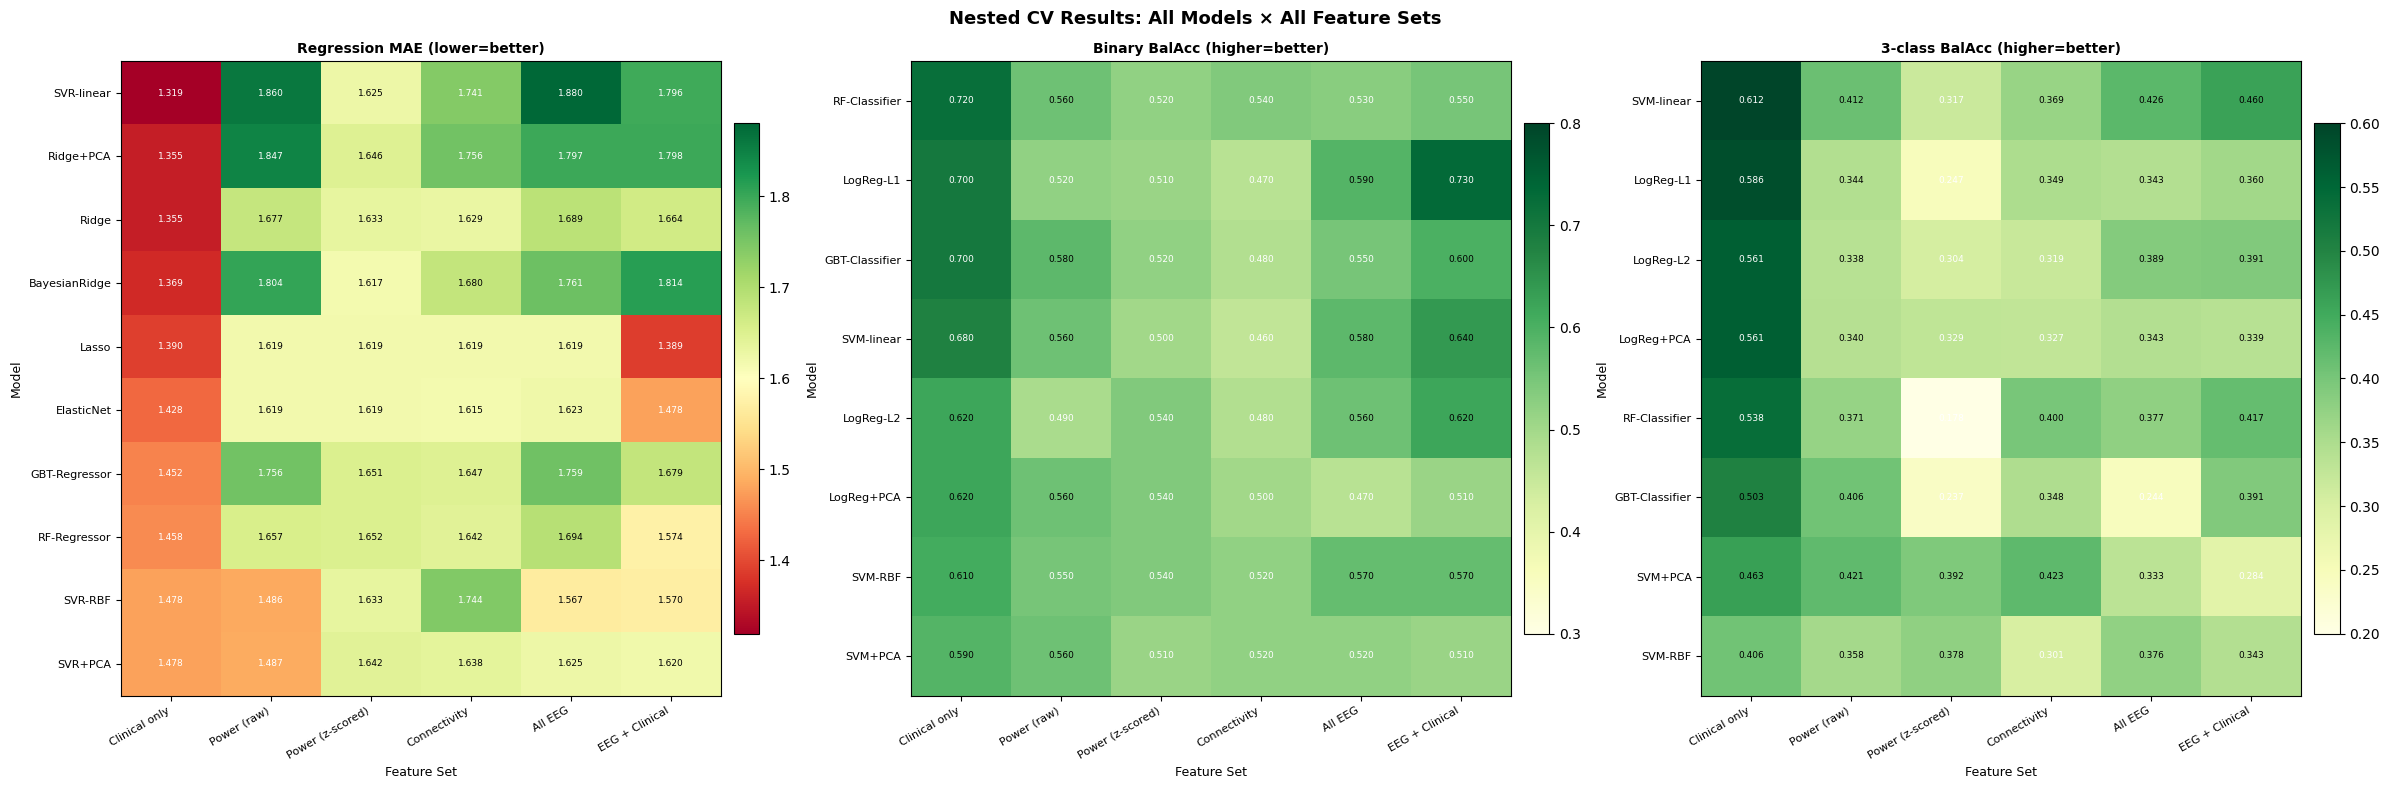

In [37]:
# ── 5b. Heatmap: all models × all feature sets (pure matplotlib) ─────────────
def make_heatmap(results_dict, metric, title, ax, vmin=None, vmax=None, cmap='YlGn'):
    # Build pivot: rows=models, cols=feature sets
    first_df = list(results_dict.values())[0]
    all_models = list(first_df['Model'])
    pivot = pd.DataFrame(index=all_models)
    for fsname, df_ in results_dict.items():
        col = df_.set_index('Model')[metric]
        pivot[fsname] = col
    pivot = pivot.fillna(np.nan).astype(float)

    data   = pivot.values
    feat_labels = list(pivot.columns)
    model_labels = list(pivot.index)

    im = ax.imshow(data, aspect='auto', cmap=cmap,
                   vmin=vmin if vmin is not None else np.nanmin(data),
                   vmax=vmax if vmax is not None else np.nanmax(data))
    ax.set_xticks(range(len(feat_labels)));  ax.set_xticklabels(feat_labels, rotation=30, ha='right', fontsize=8)
    ax.set_yticks(range(len(model_labels))); ax.set_yticklabels(model_labels, fontsize=8)

    # Annotate cells
    norm_vals = (data - np.nanmin(data)) / (np.nanmax(data) - np.nanmin(data) + 1e-9)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = data[i, j]
            if not np.isnan(val):
                text_color = 'white' if norm_vals[i, j] < 0.35 or norm_vals[i, j] > 0.75 else 'black'
                ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                        fontsize=6.5, color=text_color)

    plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlabel('Feature Set', fontsize=9)
    ax.set_ylabel('Model', fontsize=9)
    return pivot

fig, axes = plt.subplots(1, 3, figsize=(24, 8))

make_heatmap(reg_results_all,  'MAE_mean',    'Regression MAE (lower=better)',
             axes[0], cmap='RdYlGn')
make_heatmap(bin_results_all,  'BalAcc_mean', 'Binary BalAcc (higher=better)',
             axes[1], vmin=0.3, vmax=0.8, cmap='YlGn')
make_heatmap(tri_results_all,  'BalAcc_mean', '3-class BalAcc (higher=better)',
             axes[2], vmin=0.2, vmax=0.6, cmap='YlGn')

plt.suptitle('Nested CV Results: All Models × All Feature Sets', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Best Model Deep Dive

In [11]:
# ── 6a. Find overall best across all feature sets ────────────────────────────
best_reg_row  = reg_summary.iloc[0]   # lowest MAE
best_bin_row  = bin_summary.iloc[0]   # highest balanced accuracy
best_tri_row  = tri_summary.iloc[0]

print("Best regression  :", best_reg_row[['Feature Set','Best Model','MAE_mean']].to_dict())
print("Best binary clf  :", best_bin_row[['Feature Set','Best Model','BalAcc_mean']].to_dict())
print("Best 3-class clf :", best_tri_row[['Feature Set','Best Model','BalAcc_mean']].to_dict())

Best regression  : {'Feature Set': 'Clinical only', 'Best Model': 'SVR-linear', 'MAE_mean': 1.3194190169935816}
Best binary clf  : {'Feature Set': 'EEG + Clinical', 'Best Model': 'LogReg-L1', 'BalAcc_mean': 0.73}
Best 3-class clf : {'Feature Set': 'Clinical only', 'Best Model': 'SVM-linear', 'BalAcc_mean': 0.6122222222222222}


[Binary] LogReg-L1 on 'EEG + Clinical'
  True balanced accuracy: 0.710
  Permutation mean:       0.492 ± 0.075
  p-value:                0.0050


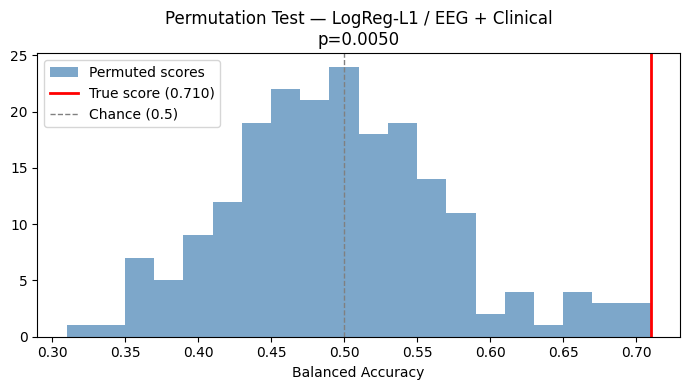

In [12]:
# ── 6b. Permutation test for best binary classifier ──────────────────────────
best_bin_fs   = best_bin_row['Feature Set']
best_bin_mdl  = best_bin_row['Best Model']

available_b = [p for p in common_ids if p in FEATURE_SETS[best_bin_fs].index]
idx_b       = [common_ids.index(p) for p in available_b]
X_best_b    = FEATURE_SETS[best_bin_fs].loc[available_b].values.astype(float)
y_best_b    = y_bin[idx_b]

# Fix NaN columns
keep = np.isnan(X_best_b).mean(axis=0) < 0.8
X_best_b = X_best_b[:, keep]

# Use the pipeline from CLF_MODELS (no grid search for permutation test)
perm_pipe_b, _ = CLF_MODELS[best_bin_mdl]

score_b, perm_scores_b, p_val_b = permutation_test_score(
    perm_pipe_b, X_best_b, y_best_b,
    scoring='balanced_accuracy',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_permutations=200, random_state=42, n_jobs=-1
)

print(f"[Binary] {best_bin_mdl} on '{best_bin_fs}'")
print(f"  True balanced accuracy: {score_b:.3f}")
print(f"  Permutation mean:       {perm_scores_b.mean():.3f} ± {perm_scores_b.std():.3f}")
print(f"  p-value:                {p_val_b:.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(perm_scores_b, bins=20, alpha=0.7, color='steelblue', label='Permuted scores')
ax.axvline(score_b, color='red', lw=2, label=f'True score ({score_b:.3f})')
ax.axvline(0.5, color='gray', lw=1, linestyle='--', label='Chance (0.5)')
ax.set_xlabel('Balanced Accuracy')
ax.set_title(f'Permutation Test — {best_bin_mdl} / {best_bin_fs}\np={p_val_b:.4f}')
ax.legend()
plt.tight_layout(); plt.show()

[Regression] SVR-linear on 'Clinical only'
  True neg-MAE:      -1.307 → MAE=1.307
  Permutation mean:  -1.743 ± 0.089
  p-value:           0.0050


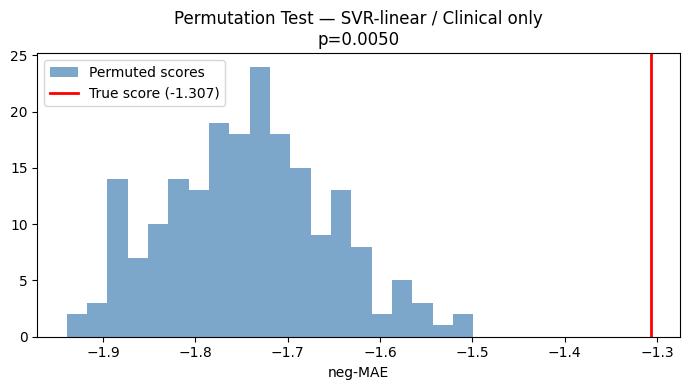

In [13]:
# ── 6c. Permutation test for best regression model ───────────────────────────
best_reg_fs  = best_reg_row['Feature Set']
best_reg_mdl = best_reg_row['Best Model']

available_r = [p for p in common_ids if p in FEATURE_SETS[best_reg_fs].index]
idx_r       = [common_ids.index(p) for p in available_r]
X_best_r    = FEATURE_SETS[best_reg_fs].loc[available_r].values.astype(float)
y_best_r    = y_reg[idx_r]

keep = np.isnan(X_best_r).mean(axis=0) < 0.8
X_best_r = X_best_r[:, keep]

perm_pipe_r, _ = REG_MODELS[best_reg_mdl]

score_r, perm_scores_r, p_val_r = permutation_test_score(
    perm_pipe_r, X_best_r, y_best_r,
    scoring='neg_mean_absolute_error',
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    n_permutations=200, random_state=42, n_jobs=-1
)

print(f"[Regression] {best_reg_mdl} on '{best_reg_fs}'")
print(f"  True neg-MAE:      {score_r:.3f} → MAE={-score_r:.3f}")
print(f"  Permutation mean:  {perm_scores_r.mean():.3f} ± {perm_scores_r.std():.3f}")
print(f"  p-value:           {p_val_r:.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(perm_scores_r, bins=20, alpha=0.7, color='steelblue', label='Permuted scores')
ax.axvline(score_r, color='red', lw=2, label=f'True score ({score_r:.3f})')
ax.set_xlabel('neg-MAE')
ax.set_title(f'Permutation Test — {best_reg_mdl} / {best_reg_fs}\np={p_val_r:.4f}')
ax.legend()
plt.tight_layout(); plt.show()

## 7. Feature Importance & Interpretability

In [14]:
# ── 7a. Fit best binary classifier on full data and inspect coefficients/importances
best_bin_fs   = best_bin_row['Feature Set']
best_bin_mdl  = best_bin_row['Best Model']

available_b = [p for p in common_ids if p in FEATURE_SETS[best_bin_fs].index]
idx_b       = [common_ids.index(p) for p in available_b]
X_full_b    = FEATURE_SETS[best_bin_fs].loc[available_b].values.astype(float)
y_full_b    = y_bin[idx_b]
feat_names  = list(FEATURE_SETS[best_bin_fs].columns)

keep_b      = np.isnan(X_full_b).mean(axis=0) < 0.8
X_full_b    = X_full_b[:, keep_b]
feat_names_b = [feat_names[i] for i, k in enumerate(keep_b) if k]

pipe_b, pgrid_b = CLF_MODELS[best_bin_mdl]
if pgrid_b:
    inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)
    gs_b  = GridSearchCV(pipe_b, pgrid_b, cv=inner, scoring='balanced_accuracy', n_jobs=-1)
    gs_b.fit(X_full_b, y_full_b)
    best_pipe_b = gs_b.best_estimator_
    print(f"Best params: {gs_b.best_params_}")
else:
    pipe_b.fit(X_full_b, y_full_b)
    best_pipe_b = pipe_b

print(f"Fitted {best_bin_mdl} on full dataset")

Best params: {'model__C': 1}
Fitted LogReg-L1 on full dataset


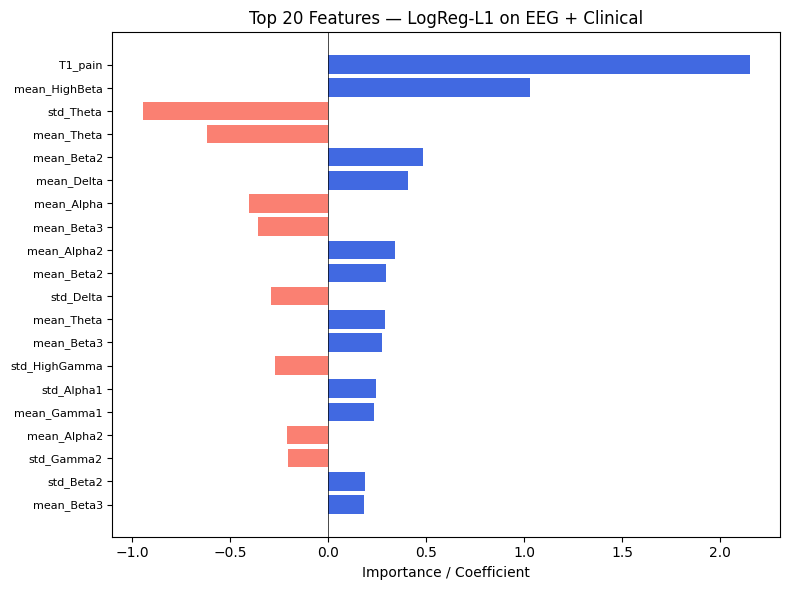

In [15]:
# ── 7b. Extract and plot feature importances ─────────────────────────────────
def get_importances(pipe, feat_names):
    mdl = pipe.named_steps['model']
    # Handle PCA: we can only show PC coefficients mapped back to original features
    pca = pipe.named_steps.get('pca', None)

    if hasattr(mdl, 'coef_'):
        coef = mdl.coef_.ravel()
        if pca is not None:
            # Map PC weights back through PCA components
            coef_orig = coef @ pca.components_  # (n_orig_features,)
            return feat_names, coef_orig
        return feat_names, coef
    elif hasattr(mdl, 'feature_importances_'):
        return feat_names, mdl.feature_importances_
    else:
        return None, None

names_b, imp_b = get_importances(best_pipe_b, feat_names_b)

if imp_b is not None:
    top_k = 20
    sorted_idx = np.argsort(np.abs(imp_b))[::-1][:top_k]
    top_names  = [names_b[i] for i in sorted_idx]
    top_vals   = imp_b[sorted_idx]

    fig, ax = plt.subplots(figsize=(8, 6))
    colors = ['royalblue' if v >= 0 else 'salmon' for v in top_vals]
    ax.barh(range(top_k), top_vals[::-1], color=colors[::-1])
    ax.set_yticks(range(top_k))
    ax.set_yticklabels(top_names[::-1], fontsize=8)
    ax.axvline(0, color='black', lw=0.5)
    ax.set_title(f'Top {top_k} Features — {best_bin_mdl} on {best_bin_fs}')
    ax.set_xlabel('Importance / Coefficient')
    plt.tight_layout(); plt.show()
else:
    print(f"Model {best_bin_mdl} does not expose feature importances / coefficients.")

LOO balanced accuracy: 0.720


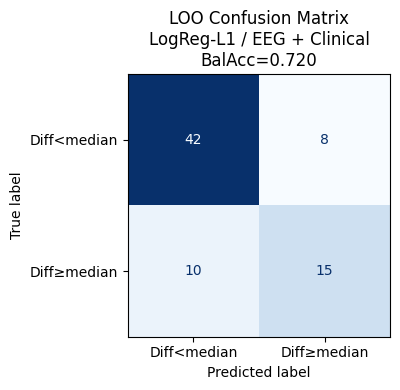

In [16]:
# ── 7c. Confusion matrix for best binary classifier (leave-one-out) ──────────
from sklearn.model_selection import LeaveOneOut, cross_val_predict

# Use the best pipeline but without inner GridSearch for speed
loo = LeaveOneOut()
y_pred_loo = cross_val_predict(
    best_pipe_b, X_full_b, y_full_b,
    cv=loo, method='predict'
)

bacc_loo = balanced_accuracy_score(y_full_b, y_pred_loo)
print(f"LOO balanced accuracy: {bacc_loo:.3f}")

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_full_b, y_pred_loo,
    display_labels=['Diff<median', 'Diff≥median'],
    ax=ax, colorbar=False, cmap='Blues'
)
ax.set_title(f'LOO Confusion Matrix\n{best_bin_mdl} / {best_bin_fs}\nBalAcc={bacc_loo:.3f}')
plt.tight_layout(); plt.show()

## 8. Univariate Feature Screening

Screening 28 unique features across 75 patients


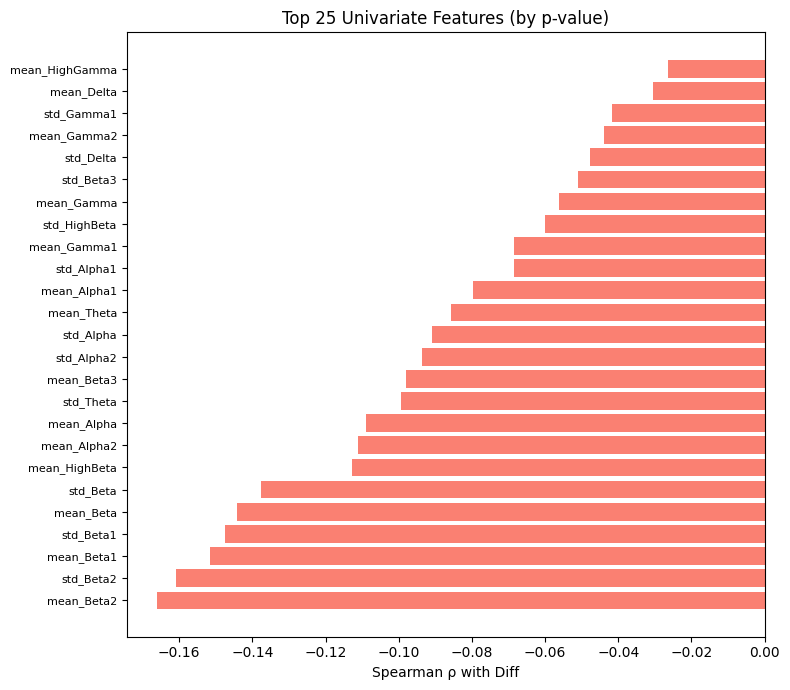


Top 10 features by p-value:
      feature       rho     pval
   mean_Beta2 -0.165957 0.154742
    std_Beta2 -0.160951 0.167747
   mean_Beta1 -0.151459 0.194583
    std_Beta1 -0.147376 0.207027
    mean_Beta -0.144217 0.217038
     std_Beta -0.137639 0.238964
mean_HighBeta -0.112884 0.334912
  mean_Alpha2 -0.111153 0.342424
   mean_Alpha -0.108902 0.352346
    std_Theta -0.099309 0.396609


In [17]:
# ── 8. Univariate correlations: which features correlate most with Diff? ─────
diff_aligned = pd.Series(y_reg, index=common_ids)

all_eeg_aligned = all_eeg_df.reindex(common_ids).copy()
n_dup = all_eeg_aligned.columns.duplicated().sum()
if n_dup > 0:
    print(f"Warning: {n_dup} duplicate columns detected — dropping duplicates. Re-run cell 8 to fix at source.")
    all_eeg_aligned = all_eeg_aligned.loc[:, ~all_eeg_aligned.columns.duplicated()]
print(f"Screening {all_eeg_aligned.shape[1]} unique features across {all_eeg_aligned.shape[0]} patients")

corr_rows = []
for col in all_eeg_aligned.columns:
    x = all_eeg_aligned[col]
    if isinstance(x, pd.DataFrame):
        continue
    x = x.dropna()
    y_shared = diff_aligned[x.index].dropna()
    x = x.loc[y_shared.index]
    if len(x) < 10:
        continue
    result = stats.spearmanr(x, y_shared)
    r, p = float(result.statistic), float(result.pvalue)
    corr_rows.append({'feature': col, 'rho': r, 'pval': p})

corr_df = pd.DataFrame(corr_rows).sort_values('pval').reset_index(drop=True)

top_n = min(25, len(corr_df))
fig, ax = plt.subplots(figsize=(8, 7))
top_corrs = corr_df.head(top_n).sort_values('rho')
colors = ['royalblue' if r >= 0 else 'salmon' for r in top_corrs['rho']]
ax.barh(range(top_n), top_corrs['rho'], color=colors)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_corrs['feature'], fontsize=8)
ax.axvline(0, color='black', lw=0.5)
ax.set_xlabel('Spearman ρ with Diff')
ax.set_title(f'Top {top_n} Univariate Features (by p-value)')
plt.tight_layout(); plt.show()

print(f"\nTop 10 features by p-value:")
print(corr_df.head(10).to_string(index=False))


Top-k feature selection (SVM-RBF, binary):
 top_k  BalAcc_mean  BalAcc_std
     5         0.49        0.02
    10         0.50        0.00
    20         0.50        0.00
    50         0.50        0.00


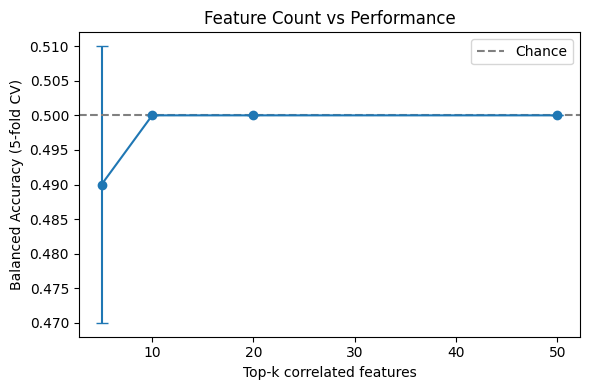

In [18]:
# ── 8b. Top-k univariate feature selection pipeline ──────────────────────────
# Build a feature set using only top-k correlated EEG features + clinical
TOP_K_LIST = [5, 10, 20, 50]

topk_results = []
for k in TOP_K_LIST:
    top_feats = corr_df.head(k)['feature'].tolist()
    X_topk = all_eeg_df.reindex(common_ids)[top_feats].values.astype(float)
    y_topk = y_bin

    keep = np.isnan(X_topk).mean(axis=0) < 0.8
    X_topk = X_topk[:, keep]

    # Drop rows with too many NaNs
    row_ok = np.isnan(X_topk).mean(axis=1) < 0.5
    X_topk_c = X_topk[row_ok]
    y_topk_c = y_topk[row_ok]

    pipe_svm, _ = CLF_MODELS['SVM-RBF']
    cv_scores   = cross_val_score(
        pipe_svm, X_topk_c, y_topk_c,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='balanced_accuracy'
    )
    topk_results.append({'top_k': k, 'BalAcc_mean': cv_scores.mean(), 'BalAcc_std': cv_scores.std()})

topk_df = pd.DataFrame(topk_results)
print("Top-k feature selection (SVM-RBF, binary):")
print(topk_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(topk_df['top_k'], topk_df['BalAcc_mean'], yerr=topk_df['BalAcc_std'],
            marker='o', capsize=4)
ax.axhline(0.5, color='gray', linestyle='--', label='Chance')
ax.set_xlabel('Top-k correlated features')
ax.set_ylabel('Balanced Accuracy (5-fold CV)')
ax.set_title('Feature Count vs Performance')
ax.legend(); plt.tight_layout(); plt.show()

## 9. Regression Scatter & Residuals

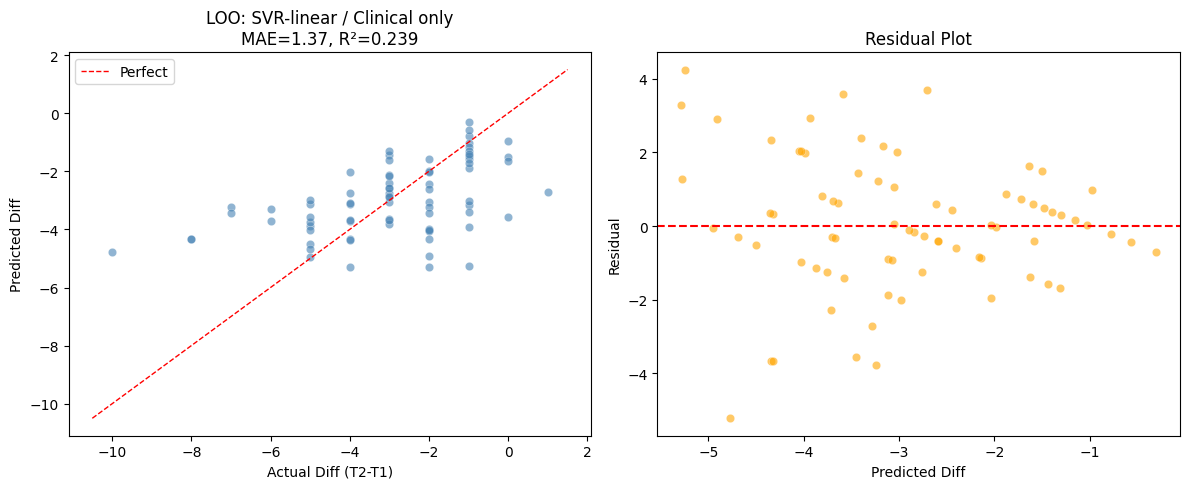

LOO MAE: 1.365  (baseline = 1.604)
LOO R²:  0.239


In [19]:
# ── 9. Predicted vs actual for best regression model (LOO) ───────────────────
best_reg_fs  = best_reg_row['Feature Set']
best_reg_mdl = best_reg_row['Best Model']

available_r = [p for p in common_ids if p in FEATURE_SETS[best_reg_fs].index]
idx_r       = [common_ids.index(p) for p in available_r]
X_full_r    = FEATURE_SETS[best_reg_fs].loc[available_r].values.astype(float)
y_full_r    = y_reg[idx_r]

keep = np.isnan(X_full_r).mean(axis=0) < 0.8
X_full_r = X_full_r[:, keep]

pipe_r, _ = REG_MODELS[best_reg_mdl]

y_pred_r_loo = cross_val_predict(
    pipe_r, X_full_r, y_full_r,
    cv=LeaveOneOut()
)

loo_mae = mean_absolute_error(y_full_r, y_pred_r_loo)
loo_r2  = r2_score(y_full_r, y_pred_r_loo)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scatter: predicted vs actual
axes[0].scatter(y_full_r, y_pred_r_loo, alpha=0.6, color='steelblue', edgecolors='white', lw=0.3)
lims = [min(y_full_r.min(), y_pred_r_loo.min()) - 0.5,
        max(y_full_r.max(), y_pred_r_loo.max()) + 0.5]
axes[0].plot(lims, lims, 'r--', lw=1, label='Perfect')
axes[0].set_xlabel('Actual Diff (T2-T1)')
axes[0].set_ylabel('Predicted Diff')
axes[0].set_title(f'LOO: {best_reg_mdl} / {best_reg_fs}\nMAE={loo_mae:.2f}, R²={loo_r2:.3f}')
axes[0].legend()

# Residuals
residuals = y_full_r - y_pred_r_loo
axes[1].scatter(y_pred_r_loo, residuals, alpha=0.6, color='orange', edgecolors='white', lw=0.3)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted Diff')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot')

plt.tight_layout(); plt.show()
print(f"LOO MAE: {loo_mae:.3f}  (baseline = {baseline_mae:.3f})")
print(f"LOO R²:  {loo_r2:.3f}")

## 10. Optional: XGBoost (if installed)

In [20]:
# ── 10. Try XGBoost if available ─────────────────────────────────────────────
try:
    import xgboost as xgb
    print(f"XGBoost version: {xgb.__version__}")
    HAS_XGB = True
except ImportError:
    print('XGBoost not installed. Skipping.')
    HAS_XGB = False

if HAS_XGB:
    XGB_REG = Pipeline(make_preproc() + [
        ('model', xgb.XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05,
                                    subsample=0.8, colsample_bytree=0.8,
                                    random_state=42, verbosity=0, n_jobs=-1))
    ])
    XGB_CLF = Pipeline(make_preproc() + [
        ('model', xgb.XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.05,
                                     subsample=0.8, colsample_bytree=0.8,
                                     eval_metric='logloss', random_state=42, verbosity=0, n_jobs=-1))
    ])

    xgb_reg_results = {}
    xgb_bin_results = {}

    for fsname, fs_df in FEATURE_SETS.items():
        available = [p for p in common_ids if p in fs_df.index]
        idx = [common_ids.index(p) for p in available]
        X_raw = fs_df.loc[available].values.astype(float)
        y_r = y_reg[idx]; y_b = y_bin[idx]
        keep = np.isnan(X_raw).mean(axis=0) < 0.8
        X_raw = X_raw[:, keep]

        scores_r = cross_val_score(XGB_REG, X_raw, y_r,
                                   cv=KFold(n_splits=5, shuffle=True, random_state=42),
                                   scoring='neg_mean_absolute_error')
        scores_b = cross_val_score(XGB_CLF, X_raw, y_b,
                                   cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                                   scoring='balanced_accuracy')
        xgb_reg_results[fsname] = (-scores_r.mean(), scores_r.std())
        xgb_bin_results[fsname] = (scores_b.mean(), scores_b.std())

    print("\nXGBoost — Regression (MAE) vs Binary (BalAcc):")
    for fs in FEATURE_SETS:
        r_mae, r_std = xgb_reg_results.get(fs, (np.nan, np.nan))
        b_acc, b_std = xgb_bin_results.get(fs, (np.nan, np.nan))
        print(f"  {fs:25s}  MAE={r_mae:.3f}±{r_std:.3f}  BalAcc={b_acc:.3f}±{b_std:.3f}")

XGBoost version: 3.2.0

XGBoost — Regression (MAE) vs Binary (BalAcc):
  Clinical only              MAE=1.607±0.461  BalAcc=0.650±0.071
  Power (raw)                MAE=1.696±0.595  BalAcc=0.490±0.132
  Power (z-scored)           MAE=1.762±0.502  BalAcc=0.440±0.086
  Connectivity               MAE=1.685±0.433  BalAcc=0.460±0.037
  All EEG                    MAE=1.731±0.454  BalAcc=0.490±0.049
  EEG + Clinical             MAE=1.565±0.526  BalAcc=0.580±0.051


## 11. Summary Dashboard

In [21]:
# ── 11. Final summary ────────────────────────────────────────────────────────
print("="*70)
print("FINAL SUMMARY")
print("="*70)
print(f"\nDataset: {len(common_ids)} patients | Target: T2-T1 Pain Diff")
print(f"Diff mean: {y_reg.mean():.2f}, std: {y_reg.std():.2f}")
print()
print("BASELINES")
print(f"  Regression   — predict-mean MAE: {baseline_mae:.3f}")
print(f"  Binary clf   — balanced accuracy at chance: 0.500")
print(f"  3-class clf  — balanced accuracy at chance: 0.333")
print()
print("BEST MODELS (nested 5-fold CV)")
best_reg_mdl = best_reg_row['Best Model']
best_bin_mdl = best_bin_row['Best Model']
best_tri_mdl = best_tri_row['Best Model']
print(f"  Regression  : {best_reg_mdl} on '{best_reg_row['Feature Set']}'")
print(f"    MAE = {best_reg_row['MAE_mean']:.3f}  (Δ vs baseline = {best_reg_row['vs_baseline']:+.3f})")
print()
print(f"  Binary clf  : {best_bin_mdl} on '{best_bin_row['Feature Set']}'")
print(f"    BalAcc = {best_bin_row['BalAcc_mean']:.3f}  (Δ vs chance = {best_bin_row['vs_baseline']:+.3f})")
print()
print(f"  3-class clf : {best_tri_mdl} on '{best_tri_row['Feature Set']}'")
print(f"    BalAcc = {best_tri_row['BalAcc_mean']:.3f}  (Δ vs chance = {best_tri_row['vs_baseline']:+.3f})")
print()
print("PERMUTATION TESTS")
print(f"  Binary clf  p-value: {p_val_b:.4f}" + (" ✓ SIGNIFICANT" if p_val_b < 0.05 else " ✗ not significant"))
print(f"  Regression  p-value: {p_val_r:.4f}" + (" ✓ SIGNIFICANT" if p_val_r < 0.05 else " ✗ not significant"))

FINAL SUMMARY

Dataset: 75 patients | Target: T2-T1 Pain Diff
Diff mean: -2.95, std: 2.08

BASELINES
  Regression   — predict-mean MAE: 1.604
  Binary clf   — balanced accuracy at chance: 0.500
  3-class clf  — balanced accuracy at chance: 0.333

BEST MODELS (nested 5-fold CV)
  Regression  : SVR-linear on 'Clinical only'
    MAE = 1.319  (Δ vs baseline = +0.284)

  Binary clf  : LogReg-L1 on 'EEG + Clinical'
    BalAcc = 0.730  (Δ vs chance = +0.230)

  3-class clf : SVM-linear on 'Clinical only'
    BalAcc = 0.612  (Δ vs chance = +0.279)

PERMUTATION TESTS
  Binary clf  p-value: 0.0050 ✓ SIGNIFICANT
  Regression  p-value: 0.0050 ✓ SIGNIFICANT
